# Preprocessing - NASA C-MAPSS

Applying the decisions from the EDA notebook step by step.
The functions are in `src/features.py` so the later notebooks and the dashboard can reuse them.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from src.data import load_train, load_test, load_test_rul, add_train_rul, add_test_rul
from src.features import (CAP, WINDOW, add_condition, useful_sensors, normalize, split_engines,
                          make_windows, last_windows, rolling_features, last_rows, prepare)

## Step 1. Cap the RUL at 125

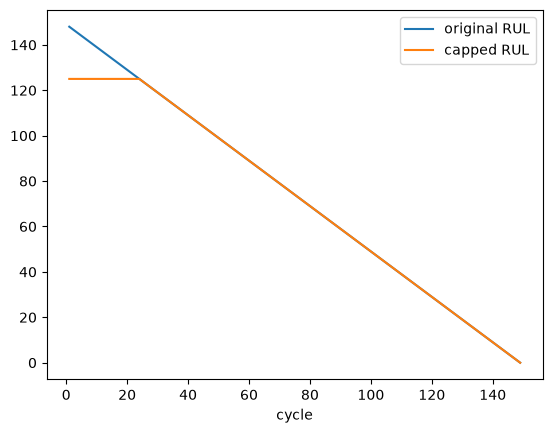

In [2]:
train = add_train_rul(load_train("FD002"), cap=CAP)
test = add_test_rul(load_test("FD002"), load_test_rul("FD002"))   # test RUL is not capped

raw = add_train_rul(load_train("FD002"))
eng = raw[raw.unit == 1]
plt.plot(eng.cycle, eng.RUL, label="original RUL")
plt.plot(eng.cycle, eng.RUL.clip(upper=CAP), label="capped RUL")
plt.xlabel("cycle")
plt.legend()
plt.show()

The target stays at 125 while the engine is healthy and only starts decreasing when degradation becomes visible.
We only cap the training labels. The test labels keep their true values so the evaluation is fair.

## Step 2. Find the operating conditions

In [3]:
train, test = add_condition(train, test)
train.condition.value_counts().sort_index()

condition
0    13458
1     8096
2     8002
3     8044
4     8037
5     8122
Name: count, dtype: int64

KMeans finds the 6 conditions. For FD001 and FD003 every row gets condition 0.

## Step 3. Choose the sensors

In [4]:
sensors = useful_sensors(train)
print(len(sensors), sensors)

14 ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


We keep sensors that change *inside* every condition. Sensors like s1 (inlet temperature) only change when the
condition changes, so they tell us nothing about wear and are dropped.

## Step 4. Normalize inside each condition

In [5]:
before = train.copy()
train, test = normalize(train, test, sensors)

print("s4 mean per condition before:", before.groupby("condition").s4.mean().round(1).tolist())
print("s4 mean per condition after: ", train.groupby("condition").s4.mean().round(2).tolist())
print("corr(s4, RUL) before:", round(before.s4.corr(before.RUL), 2), " after:", round(train.s4.corr(train.RUL), 2))

s4 mean per condition before: [1127.8, 1311.3, 1050.3, 1408.9, 1131.5, 1253.1]
s4 mean per condition after:  [-0.0, -0.0, -0.0, 0.0, -0.0, -0.0]
corr(s4, RUL) before: -0.05  after: -0.74


Means and standard deviations come from the training data only, and the same values are applied to the test data.

## Step 5. Split train / validation by engine

In [6]:
tr, va = split_engines(train)
print("train engines:", tr.unit.nunique(), " validation engines:", va.unit.nunique())
print("engines in both:", len(set(tr.unit) & set(va.unit)))

train engines: 208  validation engines: 52
engines in both: 0


We split by engine, not by row. Consecutive rows of the same engine are almost identical, so a row split
would leak information and make the validation score look better than it really is.

## Step 6. Windows for the deep learning models

In [7]:
X_train, y_train = make_windows(tr, sensors)
X_val, y_val = last_windows(va, sensors)
X_test, y_test = last_windows(test, sensors)

print("train:", X_train.shape)
print("val:  ", X_val.shape)
print("test: ", X_test.shape)

train: (36780, 30, 14)
val:   (52, 30, 14)
test:  (259, 30, 14)


Each sample is the last 30 cycles of one engine, shape `(30, n_sensors)`, and the label is the RUL at the last cycle.
For validation and test we only use the last window of each engine, because that is how the test set is scored.

In [8]:
lengths = test.groupby("unit").cycle.max()
print("test engines shorter than 30 cycles:", (lengths < WINDOW).sum(), " shortest:", lengths.min())

test engines shorter than 30 cycles: 6  shortest: 21


Short test engines are padded by repeating their first reading, so every sample has 30 rows.

## Step 7. Rolling features for the classical models

In [9]:
feats = rolling_features(train, sensors)
print(feats.shape)
feats.filter(like="s4").head()

(53759, 59)


,s4_mean,s4_std,s4_ewm,s4_slope
0,0.769983,0.000000,0.769983,0.000000
1,0.252578,0.731721,0.225346,-1.034810
2,0.027837,0.647482,-0.013395,-0.595813
3,-0.025688,0.539396,-0.063662,-0.302555
4,-0.090780,0.489281,-0.133864,-0.216369


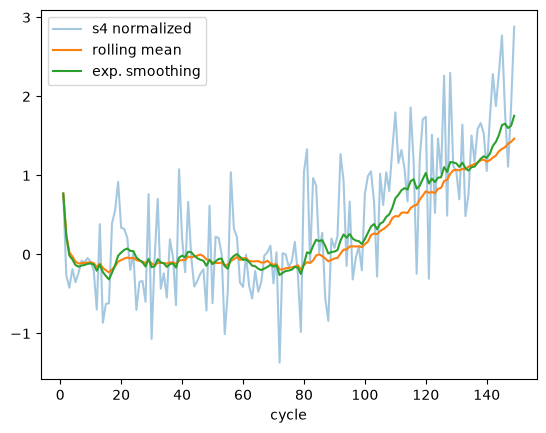

In [10]:
eng = train[train.unit == 1]
f = feats[feats.unit == 1]
plt.plot(eng.cycle, eng.s4, alpha=0.4, label="s4 normalized")
plt.plot(eng.cycle, f.s4_mean, label="rolling mean")
plt.plot(eng.cycle, f.s4_ewm, label="exp. smoothing")
plt.xlabel("cycle")
plt.legend()
plt.show()

Models like Random Forest or XGBoost can't read a sequence, so for each sensor we give them 4 summary features
of the last 30 cycles: mean, std, slope and an exponentially smoothed value. For the test set we use the last row
of each engine (`last_rows`).

## All subsets

In [11]:
for s in ["FD001", "FD002", "FD003", "FD004"]:
    train, test, sensors = prepare(s)
    X, y = make_windows(train, sensors)
    print(s, "| sensors:", len(sensors), "| windows:", X.shape, "| test engines:", test.unit.nunique())

FD001 | sensors: 14 | windows: (17731, 30, 14) | test engines: 100
FD002 | sensors: 14 | windows: (46219, 30, 14) | test engines: 259
FD003 | sensors: 16 | windows: (21820, 30, 16) | test engines: 100
FD004 | sensors: 15 | windows: (54028, 30, 15) | test engines: 248


`prepare(subset)` runs steps 1-4 in one call. Everything is ready for the baseline models in the next notebook.